In [ ]:
from pathlib import Path
import os
import re
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from esda.moran import Moran
from IPython.display import display
from libpysal.weights import KNN
from scipy.stats import chi2
from spreg import GM_Error, ML_Lag

warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mpl-cache"))
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

RAW_DATA_PATH = Path("cleaned_datasets/resale_with_all_features.parquet")
MODEL_DATA_PATH = Path("cleaned_datasets/resale_with_all_features_dummies.parquet")

# Set MAX_ROWS = None to run the full dataset. Keeping a sample cap makes the notebook runnable.
MAX_ROWS = 3000
RANDOM_STATE = 42
K_NEIGHBORS = 8
SPATIAL_METHOD = "ord"


In [36]:
raw_schema = pq.ParquetFile(RAW_DATA_PATH).schema_arrow
model_schema = pq.ParquetFile(MODEL_DATA_PATH).schema_arrow

raw_features_df = pd.DataFrame({"raw_feature": raw_schema.names})
model_features_df = pd.DataFrame({"model_feature": model_schema.names})

print(f"Raw resale dataset columns: {len(raw_schema.names)}") #33
display(raw_features_df)

print(f"Model-ready resale dataset columns: {len(model_schema.names)}") #96
display(model_features_df)


Raw resale dataset columns: 33


,raw_feature
0,month
1,year
2,town
3,flat_type
4,storey_range
5,floor_area_sqm
6,flat_model
7,remaining_lease
8,geometry
9,postal_code


Model-ready resale dataset columns: 96


,model_feature
0,month
1,year
2,floor_area_sqm
3,remaining_lease
4,geometry
5,postal_code
6,resale_price
7,num_schools_1km
8,num_schools_2km
9,num_tier1_schools_1km


### 1. Spatial Regression preparation
- This section prepares data for spatial regression modeling of housing prices, where location matters. 
- The LM tests will help determine whether a spatial lag model (price influenced by neighboring prices) or spatial error model (spatial structure in the errors) is more appropriate for the data.

In [ ]:
def parse_remaining_lease(text):
    """
    Convert remaining lease text to a numeric value in years.
    """
    text = str(text).lower()
    years_match = re.search(r"(\d+)\s*year", text)
    months_match = re.search(r"(\d+)\s*month", text)
    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0
    return years + (months / 12)


def pad_array(values, target_length):
    """
    Pad a list of values with NaN to reach a target length.
    """
    arr = np.asarray(values, dtype=float).reshape(-1)
    if len(arr) >= target_length:
        return arr[:target_length]
    return np.pad(arr, (0, target_length - len(arr)), constant_values=np.nan)


def extract_sm_results(model):
    """
    Extract results from a statsmodels OLS regression model into a DataFrame.
    """
    results_df = pd.DataFrame(
        {
            "term": model.params.index,
            "coefficient": model.params.values,
            "std_error": model.bse.values,
            "test_stat": model.tvalues.values,
            "p_value": model.pvalues.values,
        }
    )
    return results_df


def extract_spreg_results(model):
    """
    Extract results from a spreg spatial regression model into a DataFrame.
    """
    betas = np.asarray(model.betas).reshape(-1)
    names = list(getattr(model, "name_x", []))
    if len(names) != len(betas):
        names = [f"coef_{idx}" for idx in range(len(betas))]

    std_err = pad_array(getattr(model, "std_err", []), len(betas))
    stat_entries = getattr(model, "z_stat", None)
    if stat_entries is None:
        stat_entries = getattr(model, "t_stat", None)

    if stat_entries is None:
        statistics = np.repeat(np.nan, len(betas))
        p_values = np.repeat(np.nan, len(betas))
    else:
        statistics = pad_array([entry[0] for entry in stat_entries], len(betas))
        p_values = pad_array([entry[1] for entry in stat_entries], len(betas))

    return pd.DataFrame(
        {
            "term": names,
            "coefficient": betas,
            "std_error": std_err,
            "test_stat": statistics,
            "p_value": p_values,
        }
    )


def compute_lm_tests(ols_model, X_with_constant, y_series, w):
    """ 
    Compute LM-lag, LM-error, Robust LM-lag, and Robust LM-error tests based on the OLS model residuals and spatial weights.
    """
    residuals = ols_model.resid.to_numpy().reshape(-1, 1)
    fitted = ols_model.fittedvalues.to_numpy().reshape(-1, 1)
    y_array = y_series.to_numpy().reshape(-1, 1)
    x_array = X_with_constant.to_numpy()
    n = len(y_array)
    xtxi = np.asarray(ols_model.normalized_cov_params)
    sigma2_n = ((residuals.T @ residuals) / n).item()

    w_sparse = w.sparse
    wu = w_sparse @ residuals
    utwu_ds = ((residuals.T @ wu) / sigma2_n).item()
    utwy_ds = ((residuals.T @ (w_sparse @ y_array)) / sigma2_n).item()
    t_term = float(np.sum((((w_sparse.T + w_sparse) @ w_sparse).diagonal())))

    wxb = w_sparse @ fitted
    xwxb = x_array.T @ wxb
    j_num = (wxb.T @ wxb) - (xwxb.T @ xtxi @ xwxb) + (t_term * sigma2_n)
    j_term = (j_num / (n * sigma2_n)).item()

    lm_lag = float((utwy_ds ** 2) / (n * j_term))
    lm_error = float((utwu_ds ** 2) / t_term)
    robust_lm_lag = float(((utwy_ds - utwu_ds) ** 2) / ((n * j_term) - t_term))
    robust_lm_error = float(((utwu_ds - ((t_term * utwy_ds) / (n * j_term))) ** 2) / (
        t_term * (1.0 - (t_term / (n * j_term))))
    )

    return pd.DataFrame(
        [
            {"test": "LM-lag", "statistic": lm_lag, "p_value": chi2.sf(lm_lag, 1)},
            {"test": "LM-error", "statistic": lm_error, "p_value": chi2.sf(lm_error, 1)},
            {"test": "Robust LM-lag", "statistic": robust_lm_lag, "p_value": chi2.sf(robust_lm_lag, 1)},
            {"test": "Robust LM-error", "statistic": robust_lm_error, "p_value": chi2.sf(robust_lm_error, 1)},
        ]
    )


gdf = gpd.read_parquet(MODEL_DATA_PATH).copy()
full_row_count = len(gdf)

if MAX_ROWS is not None and MAX_ROWS < full_row_count:
    gdf = gdf.sample(n=MAX_ROWS, random_state=RANDOM_STATE).sort_index().copy()

gdf["remaining_lease_years"] = gdf["remaining_lease"].map(parse_remaining_lease)
gdf["log_resale_price"] = np.log(gdf["resale_price"])

################# DELETE
gdf['within_1km_tier1'] = (gdf['nearest_tier1_primary_school_dist_m'] <= 1000).astype(int)

excluded_from_x = {
    "resale_price",
    "log_resale_price",
    "geometry",
    "postal_code",
    "remaining_lease",
    "month",
    "year",
}

manual_drop_cols = {
    "flat_type_MULTI-GENERATION",
    "flat_model_Multi Generation",
    "num_schools_1km",
    "num_schools_2km",
    "nearest_tier1_primary_school_dist_m",
    "num_tier1_schools_1km",
    "num_tier1_schools_2km",  
    "num_unique_mrt_500m",
    "num_unique_mrt_1km",
    "num_unique_mrt_lines_500m",
    "num_unique_mrt_lines_1km",
    "num_busstops_500m",
    "num_busstops_1km",
    "num_malls_1km",
    "num_malls_2km",
    "num_unique_hawker_500m",
	"num_unique_hawker_1km",
}

feature_cols = [col for col in gdf.columns if col not in excluded_from_x and col not in manual_drop_cols]
model_df = gdf[["log_resale_price", "resale_price", "geometry"] + feature_cols].dropna().copy()

zero_variance_cols = [col for col in feature_cols if model_df[col].nunique() <= 1]
feature_cols = [col for col in feature_cols if col not in zero_variance_cols]

################# DELETE
################# Create a new feature list excluding any column that starts with 'town_'
feature_cols = [col for col in feature_cols if not col.startswith('town_')]

X_df = model_df[feature_cols].astype(float)
X_with_constant = sm.add_constant(X_df, has_constant="add")
y_series = model_df["log_resale_price"].astype(float)
y = y_series.to_numpy().reshape(-1, 1)
coords = np.column_stack([model_df.geometry.x.to_numpy(), model_df.geometry.y.to_numpy()])

w = KNN.from_array(coords, k=K_NEIGHBORS)
w.transform = "r"

prep_summary = pd.DataFrame(
    {
        "metric": [
            "full_dataset_rows",
            "rows_used_for_models",
            "predictor_count_used",
            "dropped_zero_variance_predictors",
            "spatial_weights",
        ],
        "value": [
            full_row_count,
            len(model_df),
            len(feature_cols),
            len(zero_variance_cols),
            f"KNN, k={K_NEIGHBORS}",
        ],
    }
)

display(prep_summary)

if zero_variance_cols:
    print("Dropped constant predictors from the current run:")
    print(zero_variance_cols)


,metric,value
0,full_dataset_rows,180003
1,rows_used_for_models,3000
2,predictor_count_used,47
3,dropped_zero_variance_predictors,1
4,spatial_weights,"KNN, k=8"


Dropped constant predictors from the current run:
['flat_model_Improved-Maisonette']


In [105]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df


def drop_high_vif_features(X, threshold=10.0, protected_features=None, verbose=True):
    """
    Iteratively drop the feature with the highest VIF above threshold.
    protected_features will never be dropped.
    """
    if protected_features is None:
        protected_features = set()
    else:
        protected_features = set(protected_features)

    X = X.copy()

    while True:
        vif_df = calculate_vif(X)
        vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)

        # only consider droppable features
        candidates = vif_df[~vif_df["feature"].isin(protected_features)]

        if candidates.empty:
            break

        max_vif_row = candidates.iloc[0]

        if max_vif_row["VIF"] <= threshold:
            break

        feature_to_drop = max_vif_row["feature"]

        if verbose:
            print(f"Dropping '{feature_to_drop}' with VIF = {max_vif_row['VIF']:.2f}")

        X = X.drop(columns=[feature_to_drop])

    return X, calculate_vif(X).sort_values("VIF", ascending=False)

X_reduced, final_vif = drop_high_vif_features(
    X_with_constant,
    threshold=10.0,
    protected_features={"floor_area_sqm", "nearest_tier1_primary_school_dist_m", "const"},
    verbose=True
)

display(final_vif)

Dropping 'flat_type_4 ROOM' with VIF = 394.69
Dropping 'flat_model_Model A' with VIF = 88.47
Dropping 'flat_type_EXECUTIVE' with VIF = 13.77


,feature,VIF
0,const,446.396210
1,floor_area_sqm,14.499375
9,flat_type_5 ROOM,6.254586
8,flat_type_3 ROOM,4.847201
30,flat_model_Improved,3.481912
43,remaining_lease_years,2.767914
28,flat_model_Apartment,2.711307
31,flat_model_Maisonette,2.510664
7,flat_type_2 ROOM,2.315643
41,flat_model_Type S1,2.026587


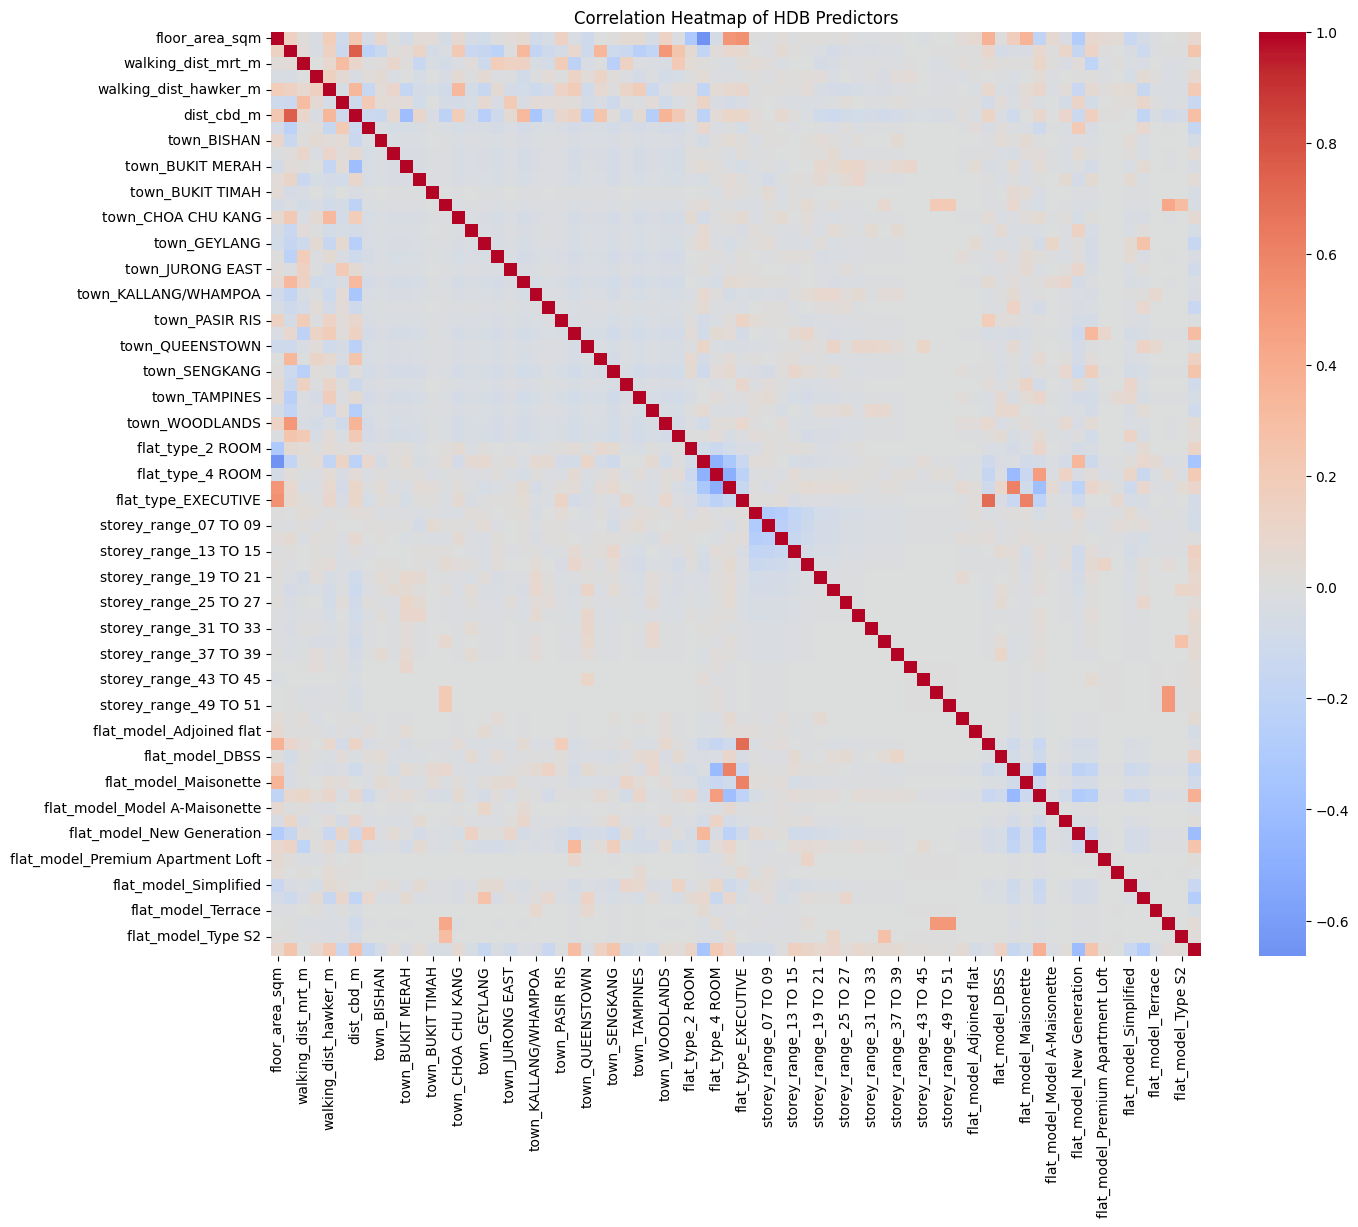

Highly correlated pairs found:


In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# We use X_df because it contains only your predictors
corr_matrix = X_df.corr()

# 2. Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix, 
    annot=False, # Set to True if you have few variables, False if many
    cmap='coolwarm', 
    center=0,
    fmt=".2f"
)
plt.title("Correlation Heatmap of HDB Predictors")
plt.show()

# Select the upper triangle of the matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.75
to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]

print("Highly correlated pairs found:")
for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.75]
    for index, value in high_corr.items():
        print(f" - {index} & {col} (Correlation: {value:.2f})")

### 2. OLS Regression

In [106]:
ols_model = sm.OLS(y_series, X_with_constant).fit()

ols_fit_df = pd.DataFrame(
    {
        "metric": ["n_obs", "predictor_count_plus_constant", "r_squared", "adj_r_squared", "aic", "bic"],
        "value": [
            int(ols_model.nobs),
            int(X_with_constant.shape[1]),
            ols_model.rsquared,
            ols_model.rsquared_adj,
            ols_model.aic,
            ols_model.bic,
        ],
    }
)

ols_results_df = extract_sm_results(ols_model)

display(ols_fit_df)
display(ols_results_df)


,metric,value
0,n_obs,"3,000.000000"
1,predictor_count_plus_constant,48.000000
2,r_squared,0.888303
3,adj_r_squared,0.886525
4,aic,"-4,977.930562"
5,bic,"-4,689.624919"


,term,coefficient,std_error,test_stat,p_value
0,const,12.140163,0.088982,136.434207,0.000000
1,floor_area_sqm,0.009051,0.000362,25.024435,0.000000
2,walking_dist_mrt_m,-0.000050,0.000004,-11.637921,0.000000
3,walking_dist_busstop_m,0.000038,0.000016,2.285260,0.022368
4,walking_dist_hawker_m,-0.000018,0.000003,-5.435069,0.000000
5,walking_dist_mall_m,-0.000001,0.000003,-0.410505,0.681465
6,dist_cbd_m,-0.000027,0.000001,-47.818880,0.000000
7,flat_type_2 ROOM,-0.133298,0.078285,-1.702721,0.088726
8,flat_type_3 ROOM,-0.005246,0.077051,-0.068090,0.945718
9,flat_type_4 ROOM,0.042682,0.076801,0.555752,0.578422


In [68]:
residual_moran = Moran(ols_model.resid.to_numpy(), w, permutations=0)
lm_results_df = compute_lm_tests(ols_model, X_with_constant, y_series, w)

moran_df = pd.DataFrame(
    [
        {
            "test": "Moran's I on OLS residuals",
            "statistic": residual_moran.I,
            "p_value": residual_moran.p_norm,
        }
    ]
)

diagnostics_df = pd.concat([moran_df, lm_results_df], ignore_index=True)
display(diagnostics_df)


,test,statistic,p_value
0,Moran's I on OLS residuals,0.261190,0.000000
1,LM-lag,42.901538,0.000000
2,LM-error,914.729893,0.000000
3,Robust LM-lag,3.633162,0.056639
4,Robust LM-error,875.461516,0.000000


### 3. Spaital Error Model

Results

1. within_1km_tier1

- coefficient = 0.018385, p = 0.030461 (statistically significant) 
- Interpretation: Flats within 1 km of a tier-1 primary school are associated with about 1.84% higher resale prices, holding the other included variables constant.

In [103]:
# GM_Error estimates the spatial error specification log(price) = Xb + u, u = lambda * W * u + eps.
sem_model = GM_Error(
    y,
    X_df.to_numpy(),
    w=w,
    name_y="log_resale_price",
    name_x=feature_cols,
    name_w=f"{K_NEIGHBORS}-NN",
)

sem_results_df = extract_spreg_results(sem_model)
sem_fit_df = pd.DataFrame(
    {
        "metric": ["lambda", "pseudo_r_squared", "sigma2", "n_obs"],
        "value": [
            float(np.asarray(sem_model.betas).reshape(-1)[-1]),
            getattr(sem_model, "pr2", np.nan),
            getattr(sem_model, "sig2", np.nan),
            sem_model.n,
        ],
    }
)

display(sem_fit_df)
display(sem_results_df)


,metric,value
0,lambda,0.716263
1,pseudo_r_squared,0.878750
2,sigma2,0.005768
3,n_obs,"3,000.000000"


,term,coefficient,std_error,test_stat,p_value
0,CONSTANT,12.189491,0.066302,183.847849,0.000000
1,floor_area_sqm,0.008068,0.000292,27.657428,0.000000
2,walking_dist_mrt_m,-0.000065,0.000007,-8.737789,0.000000
3,walking_dist_busstop_m,0.000033,0.000014,2.382278,0.017206
4,walking_dist_hawker_m,-0.000018,0.000006,-3.165961,0.001546
5,walking_dist_mall_m,0.000018,0.000004,4.686399,0.000003
6,dist_cbd_m,-0.000031,0.000001,-25.294556,0.000000
7,flat_type_2 ROOM,-0.199065,0.055689,-3.574583,0.000351
8,flat_type_3 ROOM,-0.080566,0.054652,-1.474171,0.140436
9,flat_type_4 ROOM,-0.005516,0.054519,-0.101173,0.919413


### 4. Spatial Lag Model

1. within_1km_tier1

- coefficient = 0.027435, p = 0.000000 (statistically significant) 
- Interpretation: Flats within 1 km of a tier-1 primary school are associated with about 2.74% higher resale prices, holding the other included variables constant.

In [107]:
slm_model = ML_Lag(
    y,
    X_df.to_numpy(),
    w=w,
    method=SPATIAL_METHOD,
    name_y="log_resale_price",
    name_x=feature_cols,
    name_w=f"{K_NEIGHBORS}-NN",
)

slm_results_df = extract_spreg_results(slm_model)
slm_fit_df = pd.DataFrame(
    {
        "metric": ["rho", "pseudo_r_squared", "aic", "log_likelihood", "n_obs"],
        "value": [slm_model.rho, slm_model.pr2, slm_model.aic, slm_model.logll, slm_model.n],
    }
)

model_comparison_df = pd.DataFrame(
    [
        {
            "model": "Baseline OLS hedonic",
            "fit_metric": ols_model.rsquared,
            "fit_metric_name": "R-squared",
            "spatial_parameter": np.nan,
        },
        {
            "model": "Spatial error",
            "fit_metric": getattr(sem_model, "pr2", np.nan),
            "fit_metric_name": "Pseudo R-squared",
            "spatial_parameter": float(np.asarray(sem_model.betas).reshape(-1)[-1]),
        },
        {
            "model": "Spatial lag",
            "fit_metric": slm_model.pr2,
            "fit_metric_name": "Pseudo R-squared",
            "spatial_parameter": slm_model.rho,
        },
    ]
)

display(slm_fit_df)
display(slm_results_df)
display(model_comparison_df)


,metric,value
0,rho,0.167672
1,pseudo_r_squared,0.896041
2,aic,"-5,182.285341"
3,log_likelihood,"2,640.142670"
4,n_obs,"3,000.000000"


,term,coefficient,std_error,test_stat,p_value
0,CONSTANT,9.948954,0.170813,58.244779,0.000000
1,floor_area_sqm,0.008590,0.000347,24.733065,0.000000
2,walking_dist_mrt_m,-0.000045,0.000004,-10.977941,0.000000
3,walking_dist_busstop_m,0.000039,0.000016,2.503278,0.012305
4,walking_dist_hawker_m,-0.000020,0.000003,-6.284691,0.000000
5,walking_dist_mall_m,0.000003,0.000003,0.963368,0.335363
6,dist_cbd_m,-0.000024,0.000001,-39.989241,0.000000
7,flat_type_2 ROOM,-0.137872,0.074919,-1.840285,0.065726
8,flat_type_3 ROOM,-0.009272,0.073739,-0.125746,0.899933
9,flat_type_4 ROOM,0.038638,0.073498,0.525703,0.599095


,model,fit_metric,fit_metric_name,spatial_parameter
0,Baseline OLS hedonic,0.888303,R-squared,NaN
1,Spatial error,0.878750,Pseudo R-squared,0.716263
2,Spatial lag,0.896041,Pseudo R-squared,0.167672
